## Exploratory Time Series Data Analysis

### 2.1 - Partial Autocorrelation Functions

#### Definition 2.1 — Partial Autocorrelation Function (PACF)

The **partial autocorrelation function (PACF)** at lag $k$ of a stationary time series $\{X_t\}$ with $E(X_t) = 0$ is:

**Base case ($k = 1$):**

$$\phi_{11} = \text{Corr}(X_{t-1}, X_t) = \frac{\text{Cov}(X_{t-1}, X_t)}{\left[\text{Var}(X_{t-1})\text{Var}(X_t)\right]^{1/2}} = \rho_1$$

**General case ($k \geq 2$):**

$$\phi_{kk} = \text{Corr}(\hat{Z}_{t-k}, \hat{Z}_t) = \frac{\text{Cov}(\hat{Z}_{t-k}, \hat{Z}_t)}{\left[\text{Var}(\hat{Z}_{t-k})\text{Var}(\hat{Z}_t)\right]^{1/2}}$$

where $\hat{Z}_t$ and $\hat{Z}_{t-k}$ are the **residuals** from regressing $X_t$ and $X_{t-k}$
respectively on the intervening values $\{X_{t-1}, \ldots, X_{t-k+1}\}$.

Measures the correlation between $X_{t-k}$ and $X_t$, that is not explained by intermediate time values. Would be useful for identifying reccurent or seasonality trends

#### 2.2 - White Noise Test

**portmanteau (Q) test**, which has two types: Box-Pierce and Ljung-Box

Statistical test for the outcome of the ACF, where if white noise expect 0 for all lags > 1. (asymptotically normal, mean mu, var 1/n)

#### 2.3 Simple Time Series Composition

Some simple time series models include:
1. Deterministic Trend Component
2. Deterministic Seasonality
3. Random variation component

Of which, these can be combined in a number of ways (14 different additive and multiplicative). when combining the true features of the deterministic components tend to disappear (showing how hard it is to discern these features).

#### 2.4 Time Series Decomposition and Smoothing

In practice, many realistic time series possess either deterministic seasonality (component) or a deterministic trend (component)

**Deterministic Trend**
* reflects the systematic change in the time series
* can be expressed by an aperiodic funciton T(t) = T_t

**Deterministic Seasonality**

* reflects systematic change in the time series
* seasonality is of a fixed frequency
* movement pattern in one period similar to the movement pattern in the next


the go to decomposition is either additive deterministic and seasonlaity, or all multiplicative

##### 2.4.2 - Decomposition and Smoothing Methods

Centred Moving Average - used to smooth or filter a time series, so as to estimate its deterministic trend.

#### Chapter 2 Problems

In [6]:
from PythonTsa.datadir import getdtapath
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

dtapath = getdtapath()
datasets = os.listdir(dtapath)

df = pd.read_excel(f"{dtapath}/AustraliaEmployedTotalPersons.xlsx")
print(df)

    yearandmonth     EmployedP
0     1978-02-01   5985.659716
1     1978-03-01   6040.560795
2     1978-04-01   6054.213859
3     1978-05-01   6038.264751
4     1978-06-01   6031.342299
..           ...           ...
485   2018-07-01  12572.476450
486   2018-08-01  12544.050377
487   2018-09-01  12611.208888
488   2018-10-01  12652.024422
489   2018-11-01  12739.197113

[490 rows x 2 columns]


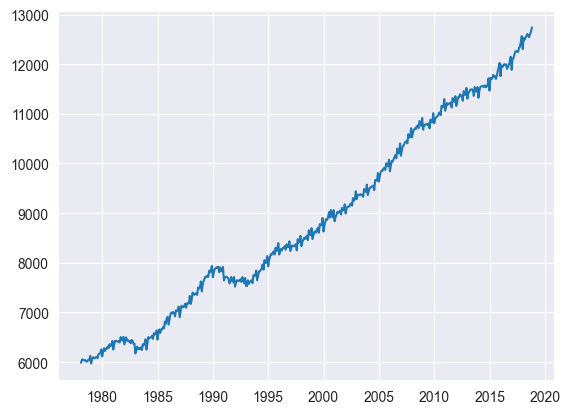

In [8]:
plt.plot(df['yearandmonth'], df['EmployedP'])

Multiplicative decomposition, assumes relationship between deterministic component and noise component is X = DSN

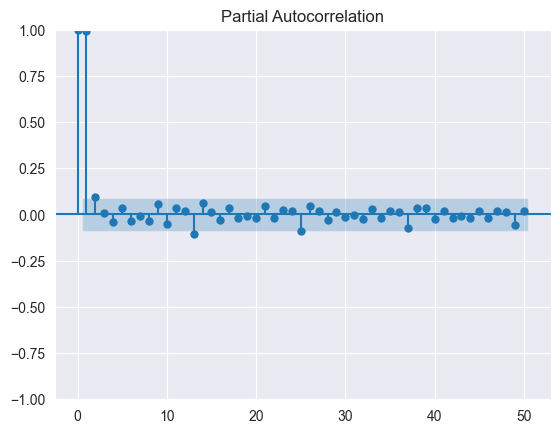

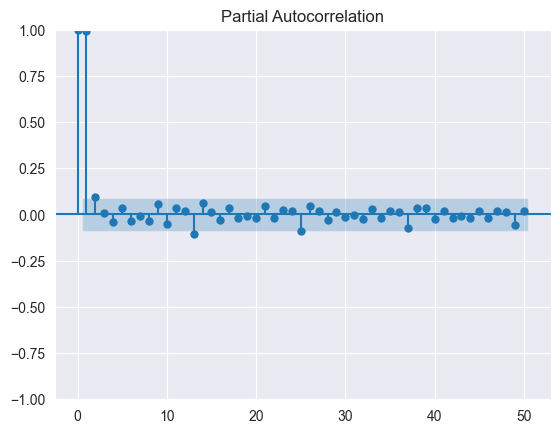

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf



plot_pacf(df['EmployedP'], lags=50)

seems to be some type of yearly seasonality

In [32]:
from statsmodels.graphics.tsaplots import month_plot



In [33]:
tidx = pd.date_range('1978-02', periods=len(df), freq='ME')
df.index = tidx
df

,EmployedP
1978-02-28,5985.659716
1978-03-31,6040.560795
1978-04-30,6054.213859
1978-05-31,6038.264751
1978-06-30,6031.342299
...,...
2018-07-31,12572.476450
2018-08-31,12544.050377
2018-09-30,12611.208888
2018-10-31,12652.024422


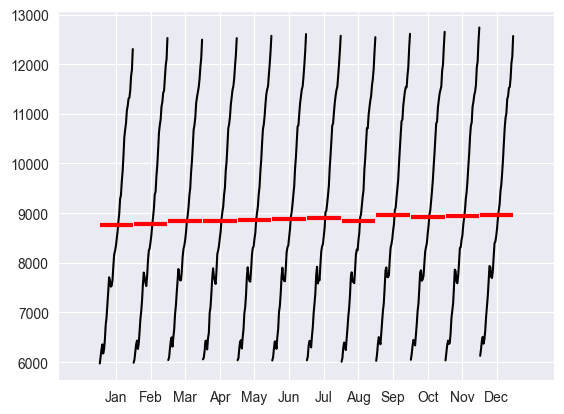

In [34]:
month_plot(df)
plt.show()

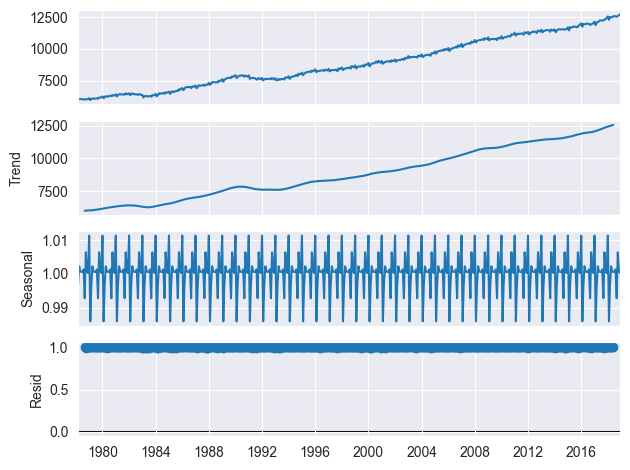

In [37]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(df, model='multiplicative')
decomp.plot()
plt.show()

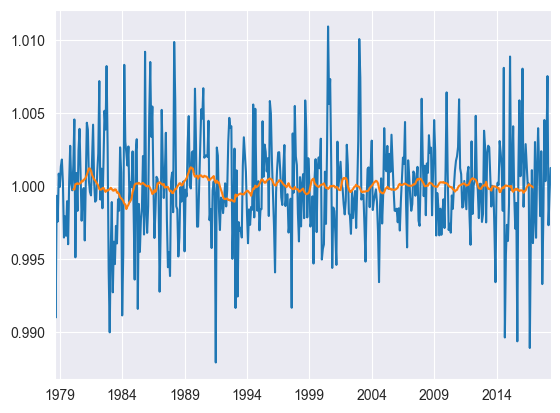

In [48]:
residuals = decomp.resid.dropna()
rolm = pd.Series.rolling(residuals, window=36, center=True).mean()
rolstd = pd.Series.rolling(residuals, window=36, center=True).std()


residuals.plot()
rolm.plot()

plt.show()

### 2.4

In [51]:
dtapath = getdtapath()
datasets = os.listdir(dtapath)

df = pd.read_csv(f"{dtapath}/gdpquarterlychina1992.1-2017.4.csv")
print(df)

          GDP
0      5234.8
1      6536.8
2      7122.5
3      8174.3
4      6803.1
..        ...
99   211151.4
100  180385.3
101  200558.7
102  211595.5
103  234582.2

[104 rows x 1 columns]


<Axes: >

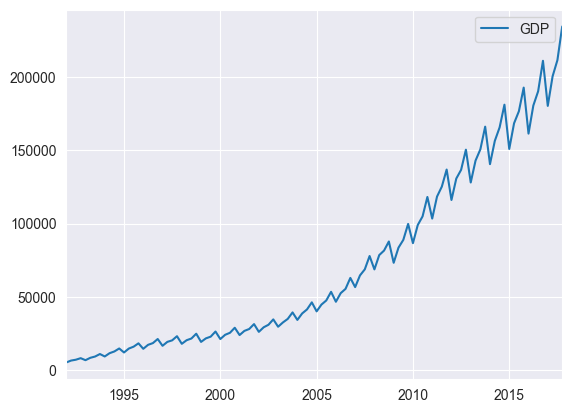

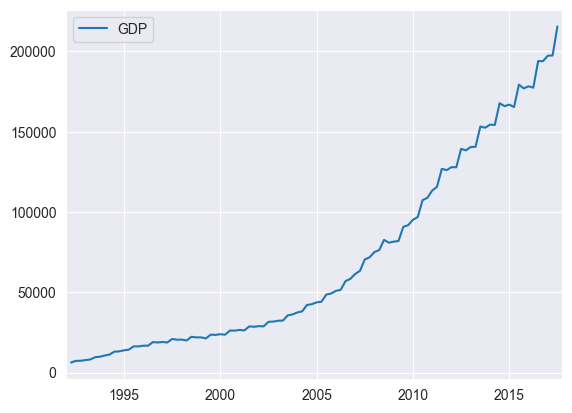

In [67]:
time_idx = pd.date_range('1992', periods=len(df), freq='QE')
df.index = time_idx

df_smooth = df.rolling(window=3, center=True).mean()

df.plot()
df_smooth.plot()



In [ ]:
# Multiplicative Holt - Winters Smoother

**Holt Winters Smoother** Uses exponentially weighted moving averages to update the estimates of three components of a time series with a trend and seasonality.

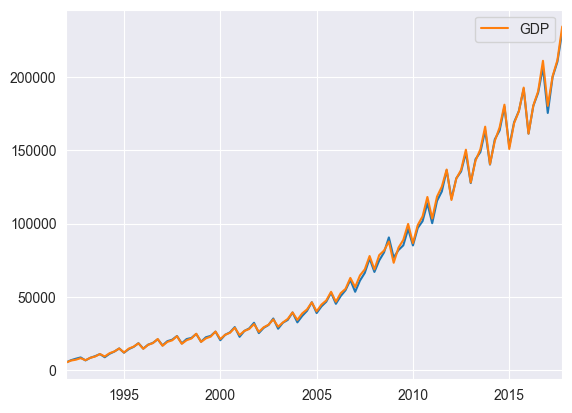

In [83]:
### Multiplicative Holt Winters Smoothing

from statsmodels.tsa.holtwinters import ExponentialSmoothing

xhwfit = ExponentialSmoothing(df, trend='add', seasonal='mul', seasonal_periods=4).fit(smoothing_trend=0.05)

fig, ax = plt.subplots()
xhwfit.fittedvalues.plot(ax = ax)
df.plot(ax = ax)

plt.show()

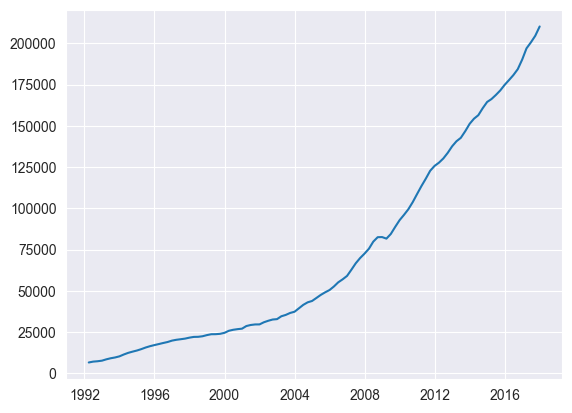

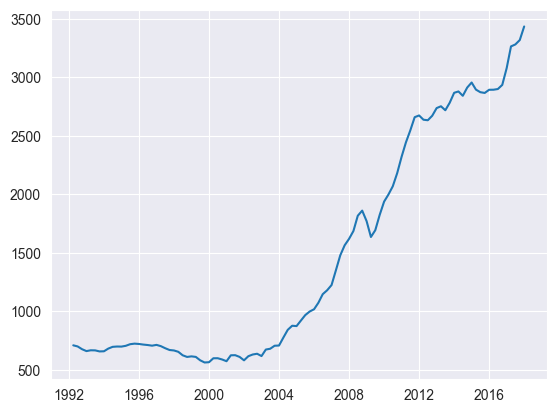

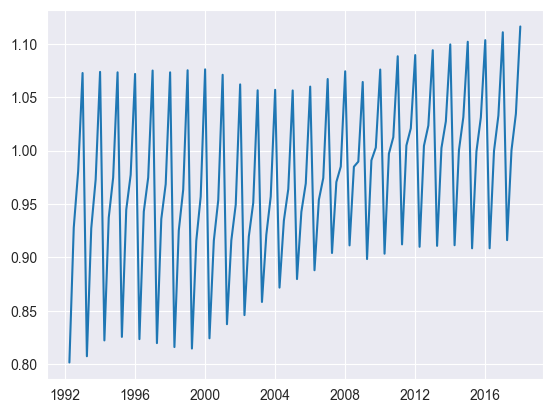

In [84]:
plt.plot(xhwfit.level)
plt.show()
plt.plot(xhwfit.trend)
plt.show()
plt.plot(xhwfit.season)
plt.show()


**seasonal periods just tells the model how many time peridos make up one full seasonal cycle**

### BTC Price Exploratory Time Series Data Analysis

In [90]:
from PythonTsa.datadir import getdtapath
import os
dtapath = getdtapath()
df = pd.read_excel(f"{dtapath}/BitcoinPrice17-6-23-18-6-22.xlsx")

# data is daily
df = df['ClosingP']
df

0      2674.9
1      2502.6
2      2477.7
3      2394.6
4      2521.2
        ...  
360    6709.2
361    6737.5
362    6760.4
363    6713.5
364    6042.6
Name: ClosingP, Length: 365, dtype: float64

<Axes: >

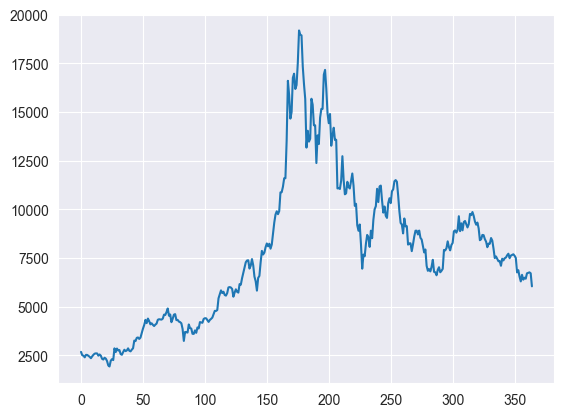

In [91]:
df.plot()

Exploratory Data Analysis - analysis correlations and possible structural breakdown. Remember that doing transforms like log diff can vastly change the structure of the data

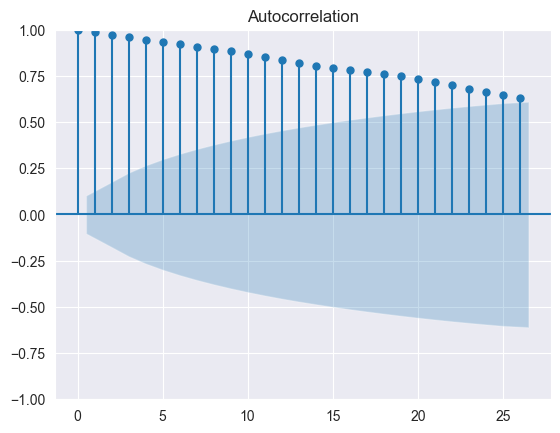

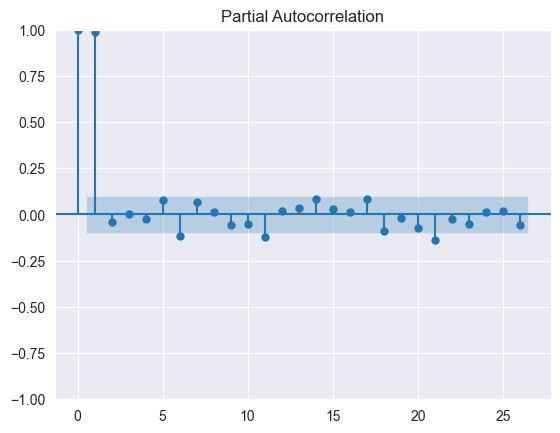

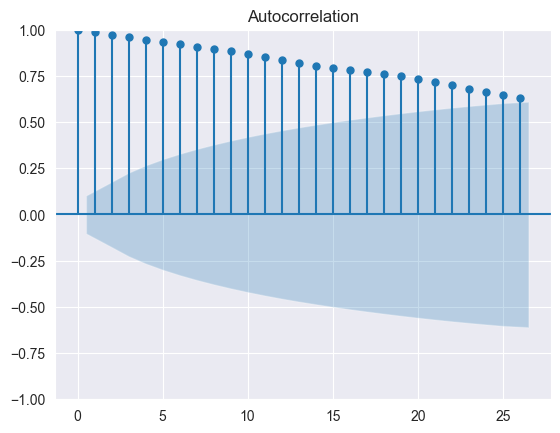

In [95]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

plot_pacf(df)
plot_acf(df)

very noisy, only real correlation with the previous value, though this is as expected

<Axes: >

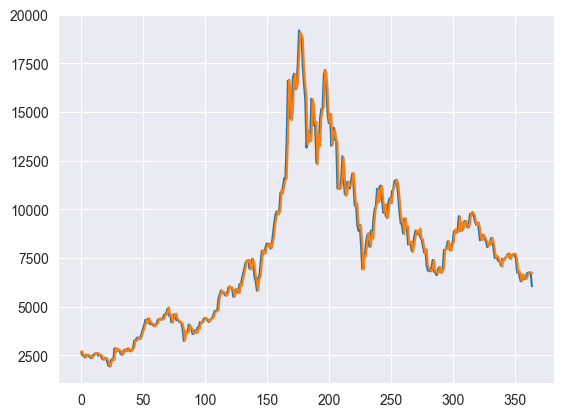

In [104]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

dfhwfit = ExponentialSmoothing(df, trend='add', seasonal='mul', seasonal_periods=7).fit()


fig, ax = plt.subplots()
df.plot(ax=ax)
dfhwfit.fittedvalues.plot(ax=ax)

Analysis of the Decomposition of the HW Fit

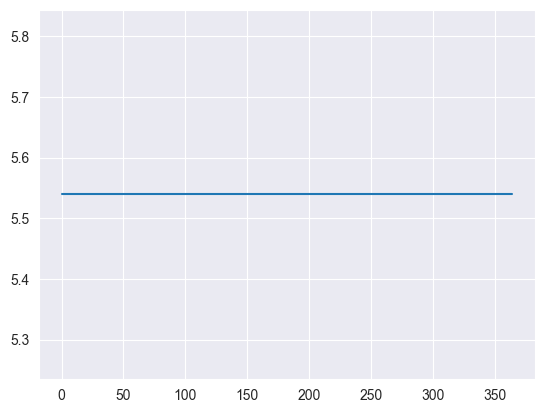

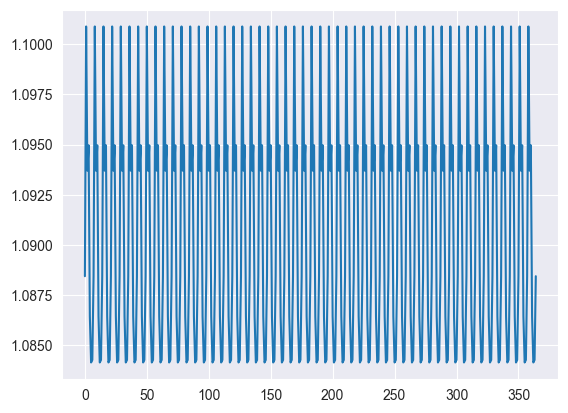

In [106]:
dfhwfit.trend.plot()
plt.show()
dfhwfit.season.plot()
plt.show()

In [103]:
dfhwfit.trend

0     -4.317368
1     -4.317368
2     -4.317368
3     -4.317368
4     -4.317368
         ...   
360   -4.317368
361   -4.317368
362   -4.317368
363   -4.317368
364   -4.317368
Length: 365, dtype: float64

In [107]:
xhwfit.params

{'smoothing_level': np.float64(0.6962784298871599),
 'smoothing_trend': np.float64(0.05),
 'smoothing_seasonal': np.float64(0.30372157011284007),
 'damping_trend': nan,
 'initial_level': np.float64(5874.3958055832945),
 'initial_trend': np.float64(712.2435551756591),
 'initial_seasons': array([0.80482649, 0.93872173, 1.00760905, 1.09196936]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

0           NaN
1     -0.066582
2     -0.009999
3     -0.034115
4      0.051519
         ...   
360    0.041619
361    0.004209
362    0.003393
363   -0.006962
364   -0.105286
Name: ClosingP, Length: 365, dtype: float64

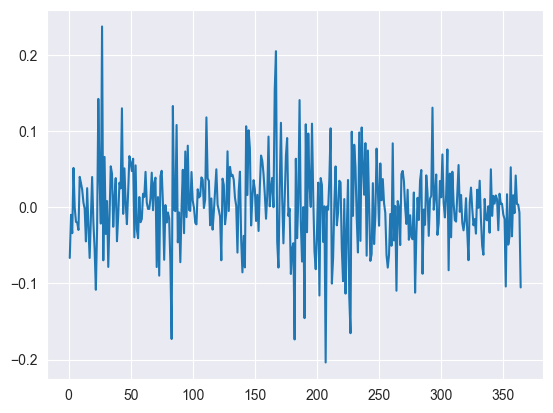

In [113]:
log_returns = np.log(df).diff()

log_returns.plot()


log_returns

(array([  4.,   3.,  21.,  64., 145.,  87.,  26.,  11.,   1.,   2.]),
 array([-0.20381047, -0.15970742, -0.11560437, -0.07150132, -0.02739827,
         0.01670478,  0.06080783,  0.10491088,  0.14901393,  0.19311699,
         0.23722004]),
 <BarContainer object of 10 artists>)

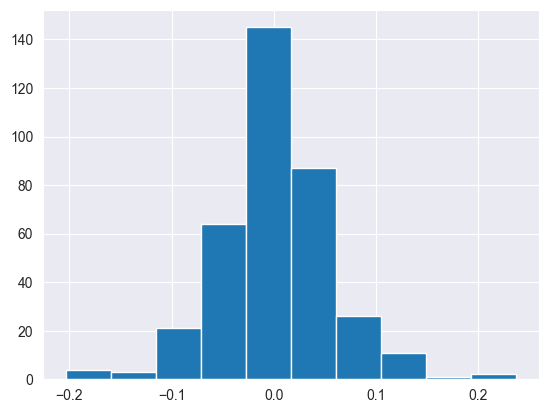

In [114]:
plt.hist(log_returns)

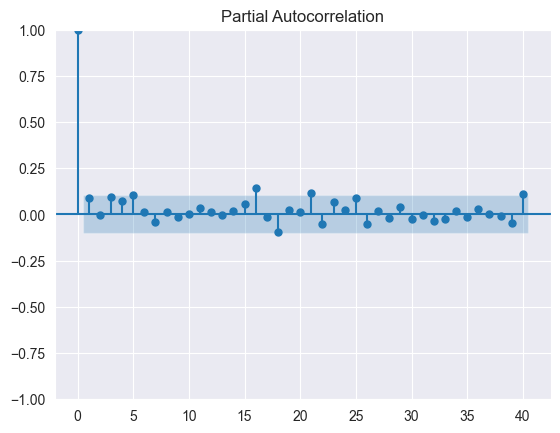

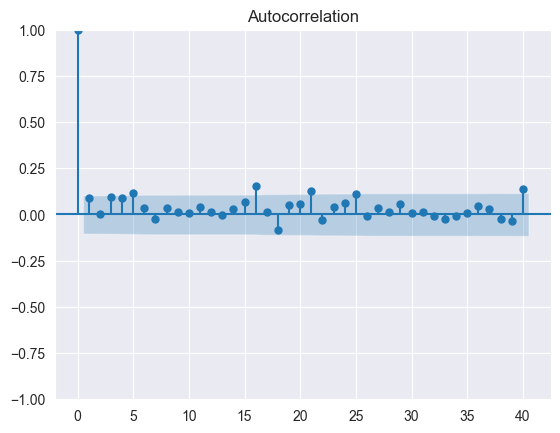

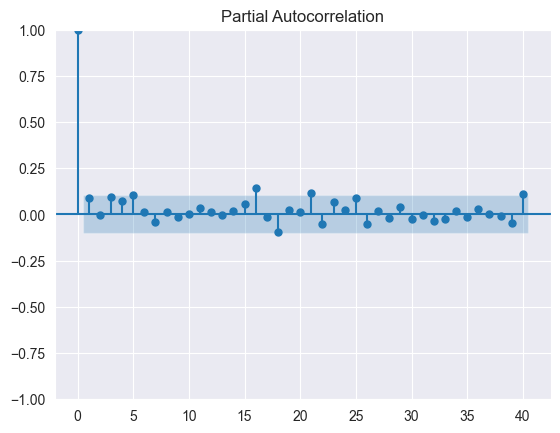

In [122]:
squared_returns = (log_returns ** 2).dropna()

plot_acf(squared_returns, lags = 40)
plot_pacf(squared_returns, lags = 40)

<Axes: >

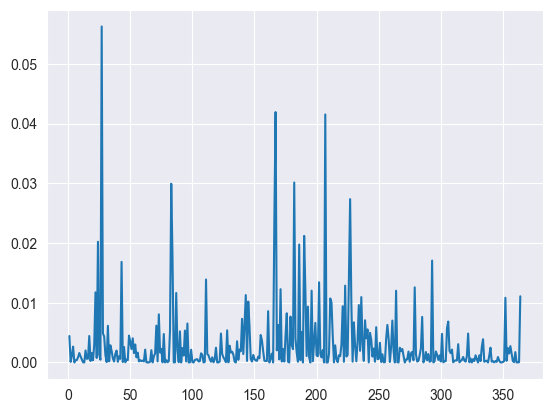

In [123]:
squared_returns.plot() # shows volatility clustering in calm vs non-calm periods. Squaring captures variance and volatility

#### Rolling mean and variance plots

<Axes: >

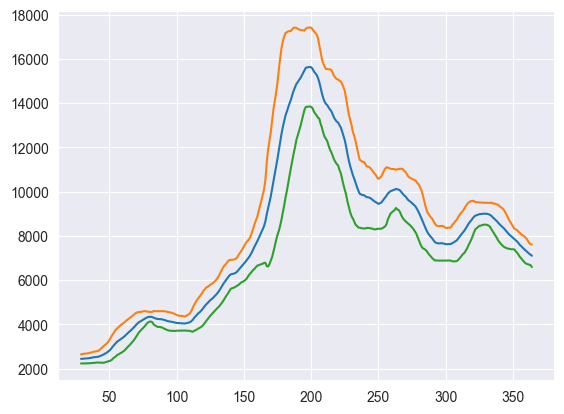

In [127]:
rolling_mean = df.rolling(window=30).mean()
rolling_std = df.rolling(window=30).std()

rolling_mean.plot()
(rolling_mean + rolling_std).plot()
(rolling_mean - rolling_std).plot()

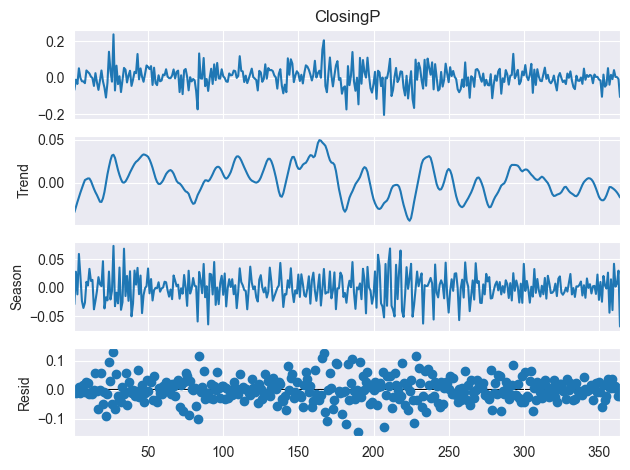

In [130]:
from statsmodels.tsa.seasonal import STL

log_returns = log_returns.dropna()

stl = STL(log_returns, period=7).fit()
stl.plot()
plt.show()